In [7]:
import numpy as np
import matplotlib.pyplot as plt
import legume
from legume import Circle, Ring

# L3 Cavity with Oxidized Holes
Optimized L3 cavity (GaAs, end-hole shift from autograd optimization) with
thin oxide rings on hole sidewalls. Sweeps oxide thickness to study effect on Q.

Bandgap: 0.2489 – 0.3274,  centre f_target = 0.2882


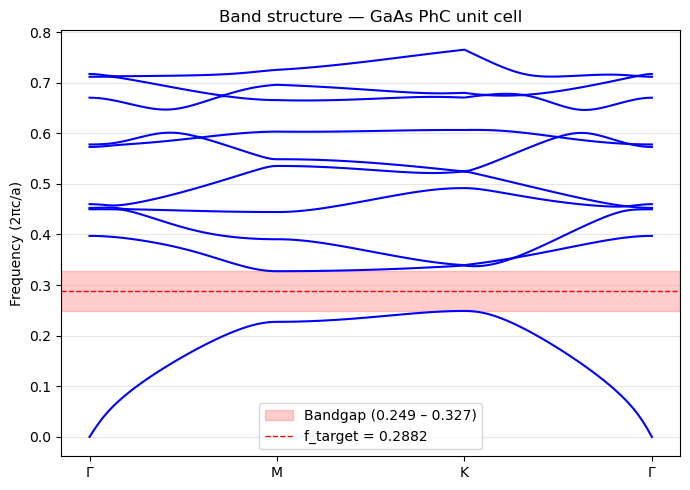

In [8]:
# ── Band structure of the perfect PhC (unit cell) ──────────────────────────

# ── Physical parameters ─────────────────────────────────────────────────────
a_nm = 250              # lattice constant in nm
ra = 75 / a_nm          # hole radius in units of a
dslab = 170 / a_nm      # slab thickness in units of a
n_slab = 3.46           # refractive index (GaAs)

lattice_unit = legume.Lattice('hexagonal')
phc_unit = legume.PhotCryst(lattice_unit)
phc_unit.add_layer(d=dslab, eps_b=n_slab**2)
phc_unit.add_shape(Circle(x_cent=0, y_cent=0, r=ra))

path_dict = lattice_unit.bz_path(['G', 'M', 'K', 'G'], [40, 40, 40])
kpoints = path_dict['kpoints']

gme_bands = legume.GuidedModeExp(phc_unit, gmax=3.0, truncate_g='tbt')
gme_bands.run(kpoints=kpoints, gmode_inds=[0], verbose=False, numeig=10)

# Find the largest complete bandgap
freqs_b = gme_bands.freqs
f_lb, f_ub, f_target = None, None, None
best_gap = 0
for i in range(freqs_b.shape[1] - 1):
    top = np.max(freqs_b[:, i])
    bot = np.min(freqs_b[:, i + 1])
    if bot > top and (bot - top) > best_gap:
        best_gap = bot - top
        f_lb, f_ub = top, bot
        f_target = (top + bot) / 2

print(f'Bandgap: {f_lb:.4f} \u2013 {f_ub:.4f},  centre f_target = {f_target:.4f}')

# Plot band structure
fig, ax = plt.subplots(figsize=(7, 5))
for i in range(freqs_b.shape[1]):
    ax.plot(freqs_b[:, i], 'b-', lw=1.5)
ax.axhspan(f_lb, f_ub, alpha=0.2, color='red',
           label=f'Bandgap ({f_lb:.3f} \u2013 {f_ub:.3f})')
ax.axhline(f_target, color='red', ls='--', lw=1,
           label=f'f_target = {f_target:.4f}')
ax.set_xticks([0, 40, 80, 120])
ax.set_xticklabels(['\u0393', 'M', 'K', '\u0393'])
ax.set_ylabel('Frequency (2\u03c0c/a)')
ax.set_title('Band structure \u2014 GaAs PhC unit cell')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# ── Supercell parameters ───────────────────────────────────────────────────
Nx, Ny = 16, 10

# Oxide material
n_oxide = 1.72
eps_oxide = n_oxide**2

# Initialize supercell lattice
lattice = legume.Lattice([Nx, 0], [0, Ny*np.sqrt(3)/2])

# Build hole positions in one quadrant (L3: skip ix=0,1 at iy=0)
xp, yp = [], []
nx, ny = Nx//2 + 1, Ny//2 + 1
for iy in range(ny):
    for ix in range(nx):
        if iy == 0 and ix in (0, 1):
            continue
        xp.append(ix + (iy%2)*0.5)
        yp.append(iy*np.sqrt(3)/2)

nc = len(xp)

# Optimized end-hole shift (from autograd optimization notebook)
dx_opt = 0.17964
dx = np.zeros(nc)
dy = np.zeros(nc)
dx[0] = dx_opt  # ic=0 → end holes at (±2, 0)

print(f'nc = {nc} holes per quadrant')
print(f'Optimized end-hole shift: dx[0] = {dx_opt}a = {dx_opt * a_nm:.1f} nm')

nc = 52 holes per quadrant
Optimized end-hole shift: dx[0] = 0.17964a = 44.9 nm


In [10]:
def cavity_oxidized(t_ox_nm):
    """Build an L3 cavity with oxide rings inside each hole.

    Parameters
    ----------
    t_ox_nm : float
        Oxide shell thickness in nm. Set to 0 for unoxidized cavity.
    """
    t_ox = t_ox_nm / a_nm  # nm → normalized units
    r_air = ra - t_ox

    phc = legume.PhotCryst(lattice)
    phc.add_layer(d=dslab, eps_b=n_slab**2)

    for ic in range(nc):
        yc = yp[ic]
        xc = xp[ic] + dx[ic] if xp[ic] != 0 else 0.0

        # Collect primary + mirror positions (same logic as L3 notebook)
        positions = [(xc, yc)]
        if nx-0.6 > xp[ic] > 0 and (ny-1.1)*np.sqrt(3)/2 > yp[ic] > 0:
            positions.append((-xc, -yc))
        if nx-1.6 > xp[ic] > 0:
            positions.append((-xc, yc))
        if (ny-1.1)*np.sqrt(3)/2 > yp[ic] > 0 and nx-1.1 > xp[ic]:
            positions.append((xc, -yc))

        for (px, py) in positions:
            if t_ox_nm > 0:
                phc.add_shape(Ring(eps=eps_oxide, r_i=r_air, r_o=ra,
                                  x_cent=px, y_cent=py))
                phc.add_shape(Circle(eps=1.0, r=r_air,
                                    x_cent=px, y_cent=py))
            else:
                phc.add_shape(Circle(x_cent=px, y_cent=py, r=ra))

    return phc

## Visualize structure

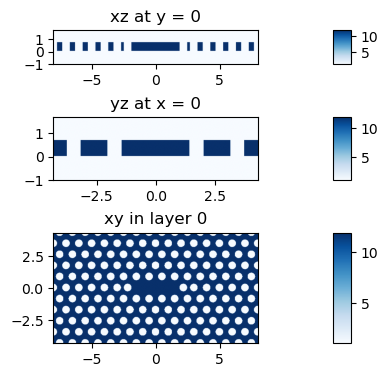

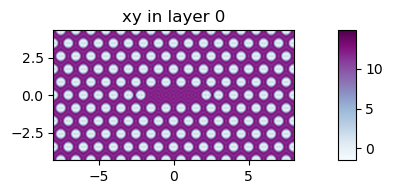

In [11]:
# Visualize the oxidized cavity (t_ox = 5 nm)
phc_viz = cavity_oxidized(5.0)
gme_viz = legume.GuidedModeExp(phc_viz, gmax=2, truncate_g='tbt')

legume.viz.structure(phc_viz, xz=True, yz=True, figsize=4, cmap='Blues',
                     Nx=400, Ny=400, Nz=200)
legume.viz.eps_ft(gme_viz, Nx=400, Ny=400, figsize=4, cbar=True, cmap='BuPu')

## Baseline: unoxidized L3 cavity

12.097s total time for real part of frequencies in GuidedModeExp, of which
  0.269s (2%) for guided modes computation using the gmode_compute='exact' method
  0.469s (4%) for inverse matrix of Fourier-space permittivity
  9.399s (78%) for matrix diagionalization using the 'eigh' solver
  1.959s (16%) for creating GME matrix
Skipping imaginary part computation, use run_im() to run it, or compute_rad() to compute the radiative rates of selected eigenmodes

Modes near bandgap centre (bandgap: 0.2489 – 0.3274):
  Mode 0: f = 0.25754,  Q = 198852.0 <-- IN BANDGAP
  Mode 1: f = 0.27028,  Q = 5372.3 <-- IN BANDGAP
  Mode 2: f = 0.27955,  Q = 726.8 <-- IN BANDGAP
  Mode 3: f = 0.28162,  Q = 253.8 <-- IN BANDGAP
  Mode 4: f = 0.28371,  Q = 274.2 <-- IN BANDGAP
  Mode 5: f = 0.29405,  Q = 1853.0 <-- IN BANDGAP
  Mode 6: f = 0.31682,  Q = 1324.3 <-- IN BANDGAP
  Mode 7: f = 0.31761,  Q = 4816.1 <-- IN BANDGAP
  Mode 8: f = 0.31990,  Q = 8921.6 <-- IN BANDGAP
  Mode 9: f = 0.32488,  Q = 2361.7 <--

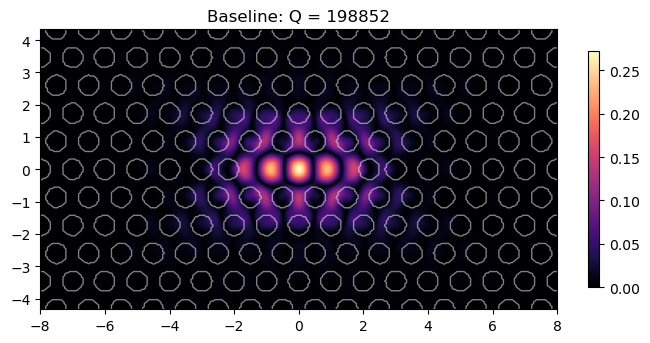

In [12]:
gmax = 2
truncate_g = 'tbt'
options = {'gmode_inds': [0], 'verbose': True, 'numeig': 10,
           'eig_sigma': f_target, 'gradients': 'approx', 'compute_im': False}

# Unoxidized cavity
phc_base = cavity_oxidized(0)
gme_base = legume.GuidedModeExp(phc_base, gmax=gmax, truncate_g=truncate_g)
gme_base.run(kpoints=np.array([[0], [0]]), **options)

# Identify the L3 cavity mode (first mode in bandgap)
print(f'\nModes near bandgap centre (bandgap: {f_lb:.4f} \u2013 {f_ub:.4f}):')
mode_idx = None
for i in range(gme_base.freqs.shape[1]):
    (freq_im_i, _, _) = gme_base.compute_rad(0, [i])
    Qi = gme_base.freqs[0, i] / (2 * freq_im_i[0])
    in_gap = f_lb < gme_base.freqs[0, i] < f_ub
    tag = ' <-- IN BANDGAP' if in_gap else ''
    print(f'  Mode {i}: f = {gme_base.freqs[0, i]:.5f},  Q = {Qi:.1f}{tag}')
    if in_gap and mode_idx is None:
        mode_idx = i

if mode_idx is None:
    raise RuntimeError('No mode found inside the bandgap')

(freq_im, _, _) = gme_base.compute_rad(0, [mode_idx])
Q_base = gme_base.freqs[0, mode_idx] / (2 * freq_im[0])
f_base = gme_base.freqs[0, mode_idx]
print(f'\nBaseline (no oxide): mode_idx = {mode_idx}, f = {f_base:.5f}, Q = {Q_base:.1f}')

ax = legume.viz.field(gme_base, 'e', 0, mode_idx, z=dslab/2,
                      component='y', val='abs', N1=300, N2=200)
plt.title(f'Baseline: Q = {Q_base:.0f}')
plt.show()

## Single oxidized run

14.924s total time for real part of frequencies in GuidedModeExp, of which
  0.115s (1%) for guided modes computation using the gmode_compute='exact' method
  0.492s (3%) for inverse matrix of Fourier-space permittivity
  12.049s (81%) for matrix diagionalization using the 'eigh' solver
  2.267s (15%) for creating GME matrix
Skipping imaginary part computation, use run_im() to run it, or compute_rad() to compute the radiative rates of selected eigenmodes
t_ox = 5.0 nm:  f = 0.25681,  Q = 201188.4
Change from baseline:  Δf = -0.00073,  ΔQ = 2336.5


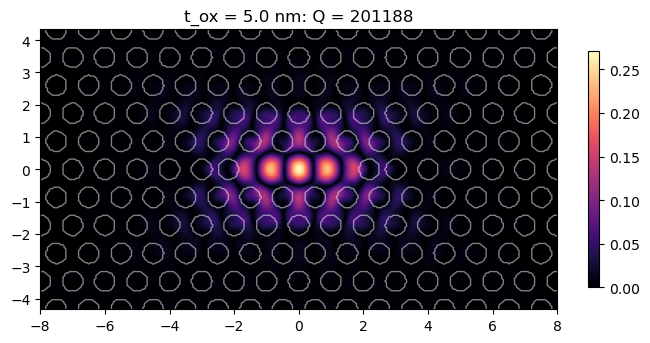

In [13]:
# Single oxidized run (t_ox = 5 nm)
t_ox_test = 5.0  # nm

phc_ox = cavity_oxidized(t_ox_test)
gme_ox = legume.GuidedModeExp(phc_ox, gmax=gmax, truncate_g=truncate_g)
gme_ox.run(kpoints=np.array([[0], [0]]), **options)

(freq_im_ox, _, _) = gme_ox.compute_rad(0, [mode_idx])
Q_ox = gme_ox.freqs[0, mode_idx] / (2 * freq_im_ox[0])
f_ox = gme_ox.freqs[0, mode_idx]

print(f't_ox = {t_ox_test} nm:  f = {f_ox:.5f},  Q = {Q_ox:.1f}')
print(f'Change from baseline:  \u0394f = {f_ox - f_base:.5f},  \u0394Q = {Q_ox - Q_base:.1f}')

ax = legume.viz.field(gme_ox, 'e', 0, mode_idx, z=dslab/2,
                      component='y', val='abs', N1=300, N2=200)
plt.title(f't_ox = {t_ox_test} nm: Q = {Q_ox:.0f}')
plt.show()

## Q factor vs oxide thickness

In [14]:
# Sweep oxide thickness
t_ox_values = np.linspace(0, 10, 21)  # nm
Qs = []
freqs_cav = []

options_sweep = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
                 'gradients': 'approx', 'compute_im': False}

f_prev = f_base  # seed tracking with baseline L3 frequency

print('Sweeping oxide thickness:')
for t_ox_nm in t_ox_values:
    phc_s = cavity_oxidized(t_ox_nm)
    gme_s = legume.GuidedModeExp(phc_s, gmax=gmax, truncate_g=truncate_g)
    gme_s.run(kpoints=np.array([[0], [0]]), eig_sigma=f_prev, **options_sweep)

    # Track the L3 mode by frequency continuity
    all_freqs = gme_s.freqs[0, :]
    mind = int(np.argmin(np.abs(all_freqs - f_prev)))

    (freq_im_s, _, _) = gme_s.compute_rad(0, [mind])
    Q_s = gme_s.freqs[0, mind] / (2 * freq_im_s[0])
    f_s = gme_s.freqs[0, mind]

    f_prev = f_s  # update reference for next step

    Qs.append(Q_s)
    freqs_cav.append(f_s)
    print(f'  t_ox = {t_ox_nm:5.2f} nm,  Q = {Q_s:10.1f},  f = {f_s:.5f}  (mode {mind})')

print('Sweep complete.')

Sweeping oxide thickness:
  t_ox =  0.00 nm,  Q =   198852.0,  f = 0.25754  (mode 8)
  t_ox =  0.50 nm,  Q =   199387.8,  f = 0.25746  (mode 8)
  t_ox =  1.00 nm,  Q =   199852.9,  f = 0.25739  (mode 8)
  t_ox =  1.50 nm,  Q =   200248.3,  f = 0.25732  (mode 8)
  t_ox =  2.00 nm,  Q =   200575.1,  f = 0.25724  (mode 8)
  t_ox =  2.50 nm,  Q =   200834.9,  f = 0.25717  (mode 8)
  t_ox =  3.00 nm,  Q =   201029.3,  f = 0.25710  (mode 8)
  t_ox =  3.50 nm,  Q =   201159.8,  f = 0.25702  (mode 8)
  t_ox =  4.00 nm,  Q =   201228.5,  f = 0.25695  (mode 8)
  t_ox =  4.50 nm,  Q =   201237.4,  f = 0.25688  (mode 8)
  t_ox =  5.00 nm,  Q =   201188.4,  f = 0.25681  (mode 8)
  t_ox =  5.50 nm,  Q =   201083.9,  f = 0.25674  (mode 8)
  t_ox =  6.00 nm,  Q =   200926.0,  f = 0.25667  (mode 8)
  t_ox =  6.50 nm,  Q =   200717.1,  f = 0.25660  (mode 8)
  t_ox =  7.00 nm,  Q =   200459.4,  f = 0.25653  (mode 8)
  t_ox =  7.50 nm,  Q =   200155.4,  f = 0.25646  (mode 8)
  t_ox =  8.00 nm,  Q =   1998

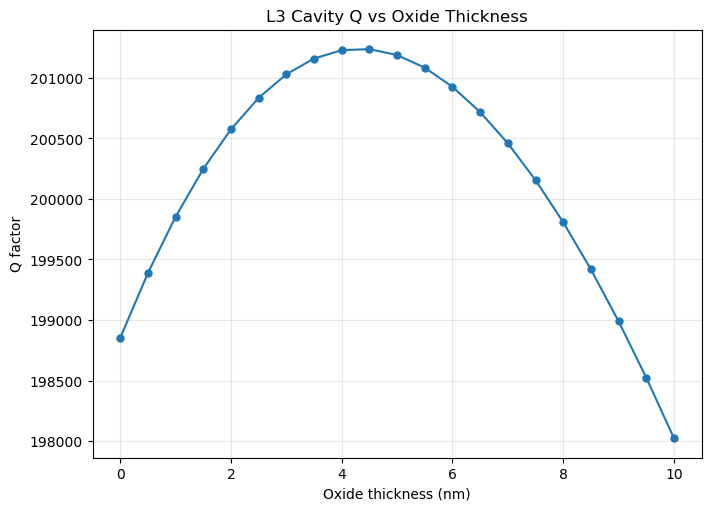

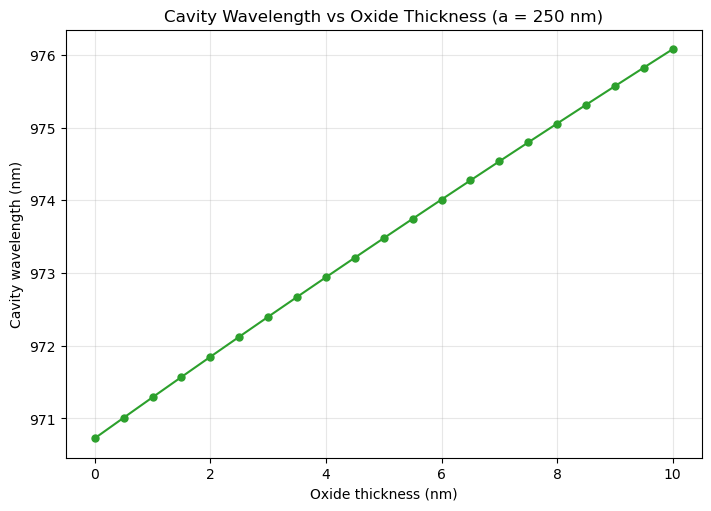

 t_ox (nm)           Q    f (norm)      λ (nm)
-----------------------------------------------------------------
      0.00    198852.0     0.25754       970.7
      0.50    199387.8     0.25746       971.0
      1.00    199852.9     0.25739       971.3
      1.50    200248.3     0.25732       971.6
      2.00    200575.1     0.25724       971.8
      2.50    200834.9     0.25717       972.1
      3.00    201029.3     0.25710       972.4
      3.50    201159.8     0.25702       972.7
      4.00    201228.5     0.25695       972.9
      4.50    201237.4     0.25688       973.2
      5.00    201188.4     0.25681       973.5
      5.50    201083.9     0.25674       973.7
      6.00    200926.0     0.25667       974.0
      6.50    200717.1     0.25660       974.3
      7.00    200459.4     0.25653       974.5
      7.50    200155.4     0.25646       974.8
      8.00    199807.5     0.25640       975.1
      8.50    199418.0     0.25633       975.3
      9.00    198989.2     0.25626       

In [19]:
# ── Plot results ───────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(7, 5), constrained_layout=True)

# Q vs oxide thickness
ax1.plot(t_ox_values, Qs, 'o-', lw=1.5, markersize=5)
ax1.set_xlabel('Oxide thickness (nm)')
ax1.set_ylabel('Q factor')
ax1.set_title('L3 Cavity Q vs Oxide Thickness')
ax1.grid(True, alpha=0.3)


plt.show()

# ── Wavelength conversion ──────────────────────────────────────────────────
lambdas_nm = [a_nm / f for f in freqs_cav]

fig, ax3 = plt.subplots(figsize=(7, 5), constrained_layout=True)
ax3.plot(t_ox_values, lambdas_nm, 'o-', lw=1.5, markersize=5, color='tab:green')
ax3.set_xlabel('Oxide thickness (nm)')
ax3.set_ylabel('Cavity wavelength (nm)')
ax3.set_title(f'Cavity Wavelength vs Oxide Thickness (a = {a_nm} nm)')
ax3.grid(True, alpha=0.3)
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────
print('=' * 65)
print(f'{"t_ox (nm)":>10}  {"Q":>10}  {"f (norm)":>10}  {"\u03bb (nm)":>10}')
print('-' * 65)
for t, q, f, lam in zip(t_ox_values, Qs, freqs_cav, lambdas_nm):
    print(f'{t:>10.2f}  {q:>10.1f}  {f:>10.5f}  {lam:>10.1f}')
print('=' * 65)

## Q factor vs hole radius

In [20]:
# Sweep hole radius (no oxide)
ra_orig = ra  # save original value
r_nm_values = np.linspace(73, 77, 21)  # nm
Qs_r = []
freqs_r = []

options_r = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
             'gradients': 'approx', 'compute_im': False}

f_prev_r = f_base  # seed tracking with baseline L3 frequency

print('Sweeping hole radius:')
for r_nm in r_nm_values:
    ra = r_nm / a_nm  # update global ra

    phc_r = cavity_oxidized(0)
    gme_r = legume.GuidedModeExp(phc_r, gmax=gmax, truncate_g=truncate_g)
    gme_r.run(kpoints=np.array([[0], [0]]), eig_sigma=f_prev_r, **options_r)

    # Track the L3 mode by frequency continuity
    all_freqs_r = gme_r.freqs[0, :]
    mind_r = int(np.argmin(np.abs(all_freqs_r - f_prev_r)))

    (freq_im_r, _, _) = gme_r.compute_rad(0, [mind_r])
    Q_r = gme_r.freqs[0, mind_r] / (2 * freq_im_r[0])
    f_r = gme_r.freqs[0, mind_r]

    f_prev_r = f_r  # update reference for next step

    Qs_r.append(Q_r)
    freqs_r.append(f_r)
    print(f'  r = {r_nm:5.1f} nm (ra = {ra:.4f}),  Q = {Q_r:10.1f},  f = {f_r:.5f}  (mode {mind_r})')

ra = ra_orig  # restore original ra
print('Sweep complete.')

Sweeping hole radius:
  r =  73.0 nm (ra = 0.2920),  Q =   196090.6,  f = 0.25588  (mode 7)
  r =  73.2 nm (ra = 0.2928),  Q =   197500.8,  f = 0.25605  (mode 8)
  r =  73.4 nm (ra = 0.2936),  Q =   198718.0,  f = 0.25621  (mode 8)
  r =  73.6 nm (ra = 0.2944),  Q =   199719.2,  f = 0.25637  (mode 8)
  r =  73.8 nm (ra = 0.2952),  Q =   200481.3,  f = 0.25654  (mode 8)
  r =  74.0 nm (ra = 0.2960),  Q =   200981.8,  f = 0.25670  (mode 8)
  r =  74.2 nm (ra = 0.2968),  Q =   201198.7,  f = 0.25687  (mode 8)
  r =  74.4 nm (ra = 0.2976),  Q =   201111.6,  f = 0.25704  (mode 8)
  r =  74.6 nm (ra = 0.2984),  Q =   200701.8,  f = 0.25720  (mode 8)
  r =  74.8 nm (ra = 0.2992),  Q =   199953.0,  f = 0.25737  (mode 8)
  r =  75.0 nm (ra = 0.3000),  Q =   198852.0,  f = 0.25754  (mode 8)
  r =  75.2 nm (ra = 0.3008),  Q =   197388.8,  f = 0.25771  (mode 8)
  r =  75.4 nm (ra = 0.3016),  Q =   195557.7,  f = 0.25788  (mode 8)
  r =  75.6 nm (ra = 0.3024),  Q =   193357.0,  f = 0.25805  (mode 8

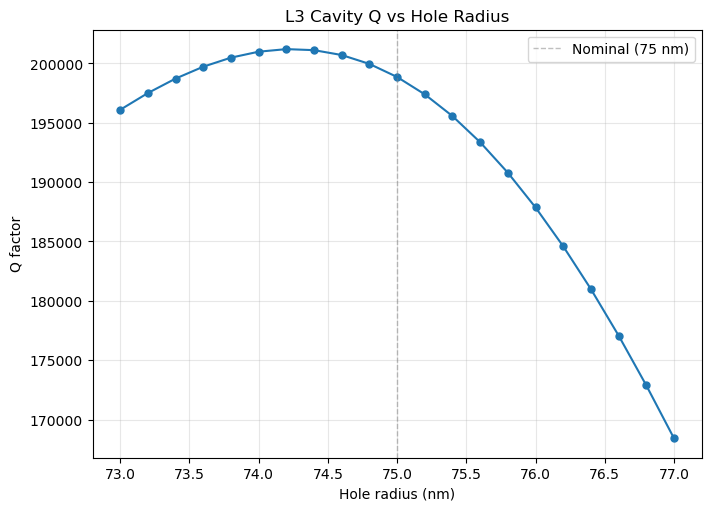

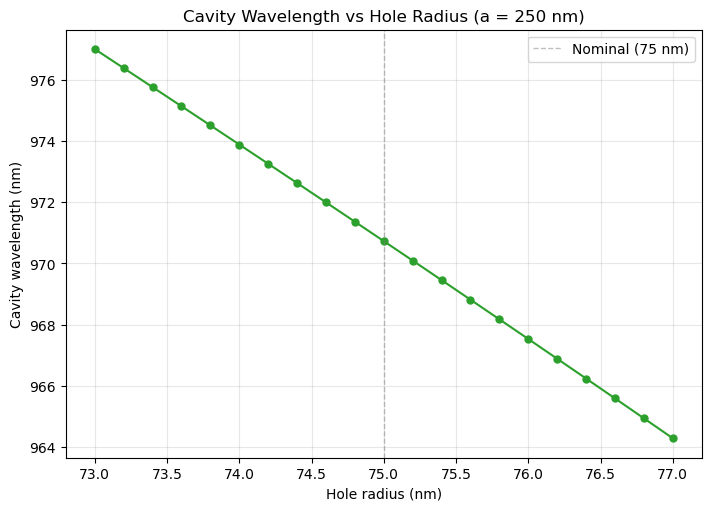

    r (nm)           Q    f (norm)      λ (nm)
-----------------------------------------------------------------
      73.0    196090.6     0.25588       977.0
      73.2    197500.8     0.25605       976.4
      73.4    198718.0     0.25621       975.8
      73.6    199719.2     0.25637       975.1
      73.8    200481.3     0.25654       974.5
      74.0    200981.8     0.25670       973.9
      74.2    201198.7     0.25687       973.3
      74.4    201111.6     0.25704       972.6
      74.6    200701.8     0.25720       972.0
      74.8    199953.0     0.25737       971.4
      75.0    198852.0     0.25754       970.7
      75.2    197388.8     0.25771       970.1
      75.4    195557.7     0.25788       969.5
      75.6    193357.0     0.25805       968.8
      75.8    190789.5     0.25822       968.2
      76.0    187862.9     0.25839       967.5
      76.2    184589.4     0.25856       966.9
      76.4    180985.8     0.25874       966.2
      76.6    177073.0     0.25891       

In [22]:
# ── Plot radius sweep results ──────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(7, 5), constrained_layout=True)

# Q vs hole radius
ax1.plot(r_nm_values, Qs_r, 'o-', lw=1.5, markersize=5)
ax1.axvline(75, color='gray', ls='--', lw=1, alpha=0.5, label='Nominal (75 nm)')
ax1.set_xlabel('Hole radius (nm)')
ax1.set_ylabel('Q factor')
ax1.set_title('L3 Cavity Q vs Hole Radius')
ax1.legend()
ax1.grid(True, alpha=0.3)


plt.show()

# ── Wavelength conversion ──────────────────────────────────────────────────
lambdas_r_nm = [a_nm / f for f in freqs_r]

fig, ax3 = plt.subplots(figsize=(7, 5), constrained_layout=True)
ax3.plot(r_nm_values, lambdas_r_nm, 'o-', lw=1.5, markersize=5, color='tab:green')
ax3.axvline(75, color='gray', ls='--', lw=1, alpha=0.5, label='Nominal (75 nm)')
ax3.set_xlabel('Hole radius (nm)')
ax3.set_ylabel('Cavity wavelength (nm)')
ax3.set_title(f'Cavity Wavelength vs Hole Radius (a = {a_nm} nm)')
ax3.legend()
ax3.grid(True, alpha=0.3)
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────
print('=' * 65)
print(f'{"r (nm)":>10}  {"Q":>10}  {"f (norm)":>10}  {"λ (nm)":>10}')
print('-' * 65)
for r, q, f, lam in zip(r_nm_values, Qs_r, freqs_r, lambdas_r_nm):
    print(f'{r:>10.1f}  {q:>10.1f}  {f:>10.5f}  {lam:>10.1f}')
print('=' * 65)